# Prophet

(Simple overview of what prophet is)

## Data preparation

In [238]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import load_data, check_stationarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [239]:
def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

In [240]:
loaded_data = load_data()
data = pd.DataFrame({
    'date': loaded_data['date'],
    'y': loaded_data['tmed']
})

data.rename(columns={'date': 'ds', 'value': 'y'}, inplace=True)

data

c:\Users\gjpin\Documents\GitHub\TSF-PROJ\utils.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['log_diff'] = np.log(selected_data['tdiff'])
c:\Users\gjpin\Documents\GitHub\TSF-PROJ\utils.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['lagged_prec'] = selected_data['prec'].shift(1)
c:\Users\gjpin\Documents\GitHub\TSF-PROJ\utils.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

,ds,y
date,,
1995-01-01,1995-01-01,9.77
1995-02-01,1995-02-01,10.87
1995-03-01,1995-03-01,12.54
1995-04-01,1995-04-01,15.11
1995-05-01,1995-05-01,17.84
...,...,...
2019-09-01,2019-09-01,20.95
2019-10-01,2019-10-01,16.75
2019-11-01,2019-11-01,12.12


In [241]:
# Use first 80% for training, last 20% for testing
split_idx = int(len(data)*0.8)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

X_train = train.drop(columns=['y'])
y_train = train['y']
X_test = test.drop(columns=['y'])
y_test = test['y']

print(len(test))
print(train.dtypes)
y_test

61
ds    datetime64[ns]
y            float64
dtype: object


date
2015-01-01     8.25
2015-02-01     8.73
2015-03-01    12.18
2015-04-01    15.08
2015-05-01    18.67
              ...  
2019-09-01    20.95
2019-10-01    16.75
2019-11-01    12.12
2019-12-01    10.99
2020-01-01     9.59
Name: y, Length: 61, dtype: float64

## Modelling

In [242]:
from prophet import Prophet

model = Prophet()
model.fit(train)
future = model.make_future_dataframe(periods=len(test), freq='MS')

future

13:23:43 - cmdstanpy - INFO - Chain [1] start processing
13:23:43 - cmdstanpy - INFO - Chain [1] done processing


,ds
0,1995-01-01
1,1995-02-01
2,1995-03-01
3,1995-04-01
4,1995-05-01
...,...
296,2019-09-01
297,2019-10-01
298,2019-11-01
299,2019-12-01


In [243]:
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
296,2019-09-01,20.236146,18.914345,21.617273
297,2019-10-01,17.119228,15.703930,18.380382
298,2019-11-01,12.325889,10.932431,13.717149
299,2019-12-01,8.988281,7.646929,10.355783
300,2020-01-01,9.085708,7.795864,10.472367


In [244]:
evaluate(y_test, forecast['yhat'][-len(test):])

MAE: 1.0170343458003706
RMSE: 1.2510661726634544


Text(0.5, 1.0, 'Prophet Forecast')

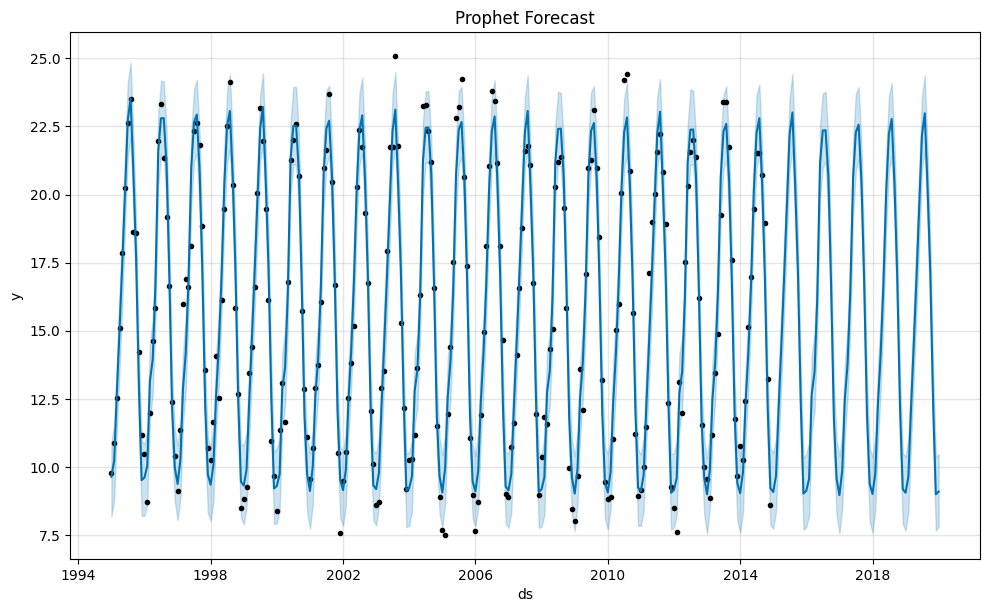

In [245]:
fig1 = model.plot(forecast)
plt.title("Prophet Forecast")

Text(0.5, 1.02, 'Prophet Forecast Components')

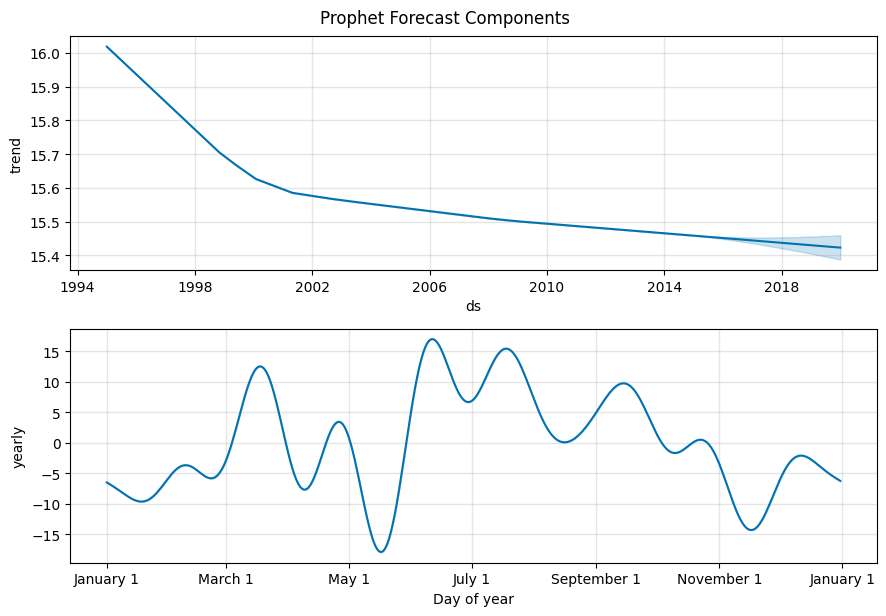

In [246]:
fig2 = model.plot_components(forecast)
plt.suptitle("Prophet Forecast Components", y=1.02)

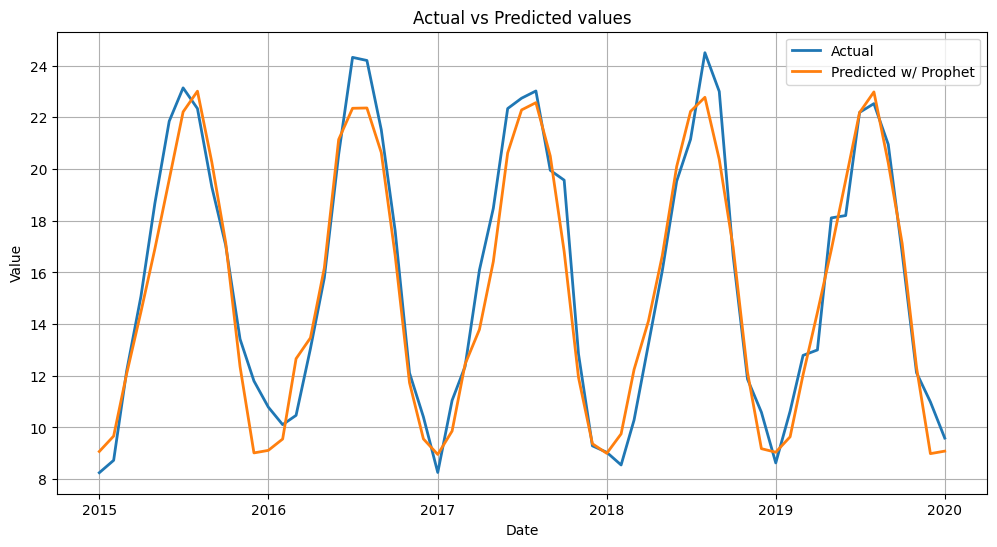

In [247]:
# Filter forecast to only the test dates
forecast_test = forecast.set_index('ds').loc[y_test.index]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, forecast_test['yhat'], label="Predicted w/ Prophet", linewidth=2)

plt.title("Actual vs Predicted values")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()